<p><center><span style='color: green; font-size: 30px'><b>Estrategia de Máximo Sharpe con Mandato de Carbono: Un Enfoque Cuantitativo</b></span></center></p>

<p><center><span style='color: blue; font-size: 28px'><b>Autor: Gonzalo Ramírez-Carrillo</b></span></center></p>

# Introducción

El cambio climático ha dejado de ser únicamente una preocupación ambiental para convertirse en un **riesgo financiero material** que afecta directamente la gestión de portafolios de inversión. Factores como los riesgos físicos, los riesgos de transición y la creciente regulación climática están redefiniendo la asignación de capital y la valoración de activos, especialmente en sectores intensivos en carbono.

En este contexto, surge la necesidad de construir portafolios que no solo optimicen la relación riesgo-retorno, sino que también incorporen criterios de sostenibilidad. Un enfoque común es la reducción de la **intensidad de carbono del portafolio**, medida a través del indicador WACI (Weighted Average Carbon Intensity), el cual captura las emisiones relativas de las empresas en función de sus ingresos.

La integración del componente climático en la gestión de portafolios se puede abordar mediante técnicas cuantitativas, extendiendo el modelo clásico de optimización de portafolio. En este marco, el problema de optimización incorpora una restricción adicional que limita la huella de carbono del portafolio, generando un nuevo espacio de decisión donde el inversionista enfrenta un **trade-off entre riesgo, retorno y sostenibilidad**.

Este enfoque permite construir portafolios alineados con objetivos climáticos —como los denominados *Paris-Aligned Portfolios*—, aunque implica costos en términos de eficiencia, ya que la restricción de carbono puede ser *binding* y desplazar la solución óptima hacia combinaciones con mayor riesgo.

El presente trabajo implementa este marco teórico en Python, maximizando el Ratio de Sharpe de un portafolio bajo una restricción de carbono y analizando el costo de eficiencia financiera (trade-off) que implica el cumplimiento de este mandato verde frente a un portafolio sin restricciones.

## 1. Librerías

En esta sección se importan las principales librerías utilizadas a lo largo del análisis y la optimización del portafolio. Cada una cumple un rol específico dentro del flujo de trabajo:

- **NumPy (`numpy`)**: Se utiliza para realizar cálculos numéricos eficientes, especialmente operaciones con vectores y matrices, fundamentales en la teoría de portafolios.

- **Pandas (`pandas`)**: Permite la manipulación y análisis de datos estructurados. Es clave para trabajar con series de tiempo de precios, retornos y métricas de carbono de los activos.

- **Matplotlib (`matplotlib.pyplot`)**: Se emplea para la visualización de resultados, como la frontera eficiente, la composición del portafolio o comparaciones entre escenarios con y sin restricciones de carbono.

- **SciPy (`scipy.optimize.minimize`)**: Contiene herramientas de optimización numérica. En este caso, se utiliza para resolver el problema de optimización del portafolio bajo restricciones, incluyendo el mandato de carbono.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## 2. Data

En esta sección se realiza la carga y preparación de los datos necesarios para el análisis del portafolio.

Primero, se importan los precios históricos de las acciones desde un archivo de Excel. Se especifica la hoja de trabajo y se define la columna de fechas como índice, lo que permite trabajar con series de tiempo de manera adecuada.

Luego, se selecciona un subconjunto de empresas que conformarán el universo de inversión. Estas corresponden a distintas industrias, lo que permite diversificación en el portafolio.

Posteriormente, se filtran únicamente estas empresas dentro del dataset original y se eliminan valores faltantes (`NaN`) para asegurar consistencia en los cálculos.

A continuación, se calculan los **retornos logarítmicos**, utilizando la fórmula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Este tipo de retornos es ampliamente utilizado en finanzas debido a sus propiedades estadísticas, como la aditividad en el tiempo.

Finalmente, se imprime:
- El número de activos (acciones) considerados en el análisis.
- El número de observaciones disponibles (periodos de tiempo).

Esto permite verificar que los datos han sido cargados y procesados correctamente antes de continuar con la optimización.

In [6]:
precios = pd.read_excel(
    'TABLA_PRECIOS_ACCIONES.xlsx',
    sheet_name='PRECIOS_ACCIONES',
    index_col='Date'
)

empresas = ['AAPL', 'AMZN', 'CAT', 'CVX', 'JNJ',
            'JPM', 'KO', 'MSFT', 'PFE', 'V', 'XOM']

precios = precios[empresas].dropna()

# Log-returns
retornos = np.log(precios / precios.shift(1)).dropna()

print(f"Número de acciones: {retornos.shape[1]}")
print(f"Número de observaciones: {retornos.shape[0]}")

Número de acciones: 11
Número de observaciones: 1254


## 3. Intensidad de carbono por empresa

En esta sección se incorpora la dimensión ambiental al modelo de optimización mediante la asignación de una **intensidad de carbono** a cada activo del portafolio. La intensidad de carbono se define como las emisiones de GEI (en toneladas métricas de CO₂e) por unidad de ingresos de la empresa. Emisiones totales de GEI * 1000 / Ventas. Fuente: Bloomberg. Fuente: Bloomberg.

El vector `intensidades_carbono` recoge este indicador para cada empresa del portafolio. A nivel agregado, permite calcular la **WACI (Weighted Average Carbon Intensity)** del portafolio.

| Ticker | Empresa               | Sector                                         | Intesidad de carbon, CI | 
|--------|-----------------------|------------------------------------------------|-------------------------|
| **AAPL** | Apple Inc.            | Tecnología (hardware/software)                | 3.27                   |
| **MSFT** | Microsoft Corp.       | Tecnología (software/cloud)                   | 41.20                  |
| **JNJ**  | Johnson & Johnson     | Salud (farmacéutica y consumo)                 | 8.73                  |
| **PFE**  | Pfizer Inc.           | Salud (farmacéutica)                           | 16.71                 |
| **XOM**  | Exxon Mobil Corp.     | Energía (petróleo y gas)                        | 294.77               |
| **CVX**  | Chevron Corp.         | Energía (petróleo y gas)                        | 284.36               |
| **JPM**  | JPMorgan Chase & Co.  | Finanzas (banca)                               | 3.13                  |
| **V**    | Visa Inc.             | Finanzas (pagos electrónicos)                  | 2.42                  |
| **KO**   | Coca-Cola Co.         | Consumo defensivo (bebidas)                    | 28.65                 |
| **CAT**  | Caterpillar Inc.      | Industrial (maquinaria pesada)                 | 22.37                 |
| **AMZN** | Amazon.com Inc.       | Consumo discrecional / e-commerce & cloud      | 52.09                 |

Finalmente, se define un **objetivo de intensidad de carbono** (`waci_target`), que representa una restricción exógena (mandato ESG) sobre el portafolio. Este valor establece el nivel máximo de intensidad de carbono permitido y condiciona la asignación óptima de activos.

En este caso:

- Se busca construir un portafolio cuya intensidad de carbono promedio ponderada no supere **47**.
- Esta restricción será incorporada más adelante en el proceso de optimización como un mandato de sostenibilidad.

In [8]:
#empresas = ['AAPL', 'AMZN', 'CAT', 'CVX', 'JNJ', 'JPM', 'KO', 'MSFT', 'PFE', 'V', 'XOM']

In [9]:
intensidades_carbono = np.array([
    3.27, 52.09, 22.37, 284.36, 8.73, 3.13, 28.65, 41.20, 16.71, 2.42, 294.77
])

# Se fija un WACI objetivo como restricción exógena (simulando un mandato ESG).
waci_target = 47

## 4. Pre-cálculos

En esta sección se calculan los principales insumos estadísticos necesarios para la optimización del portafolio, a partir de los retornos previamente obtenidos.

- **Retornos esperados (`mean_returns`)**: Se calcula el promedio de los retornos logarítmicos para cada activo y se anualiza multiplicando por 252 (número aproximado de días hábiles en un año bursátil).

- **Matriz de covarianza (`cov_matrix`)**: Se estima la covarianza entre los retornos de los activos, lo que permite capturar cómo se mueven conjuntamente. Esta matriz también se anualiza multiplicando por 252.

Estos dos elementos son fundamentales en la teoría moderna de portafolios, ya que permiten medir:
- Rentabilidad esperada
- Riesgo (volatilidad)
- Diversificación entre activos

In [11]:
mean_returns = retornos.mean() * 252
cov_matrix = retornos.cov() * 252

## 5. Funciones

En esta sección se definen las funciones clave que se utilizarán durante el proceso de optimización del portafolio, junto con su representación en notación matricial.

Sea:

- $ \mathbf{w} $: vector de pesos del portafolio  
- $ \boldsymbol{\mu} $: vector de retornos esperados  
- $ \boldsymbol{\Sigma} $: matriz de covarianza de los retornos  
- $ \mathbf{c} $: vector de intensidades de carbono  

---

- **`expected_return(weights)`**:  
  Calcula el retorno esperado del portafolio como el producto punto entre los pesos y los retornos esperados:

$$
R_p = \mathbf{w}^\top \boldsymbol{\mu}
$$

---

- **`portfolio_volatility(weights)`**:  
  Calcula la volatilidad (riesgo) del portafolio a partir de la matriz de covarianza:

$$
\sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}
$$

---

- **`portfolio_waci(weights)`**:  
  Calcula la intensidad de carbono del portafolio (WACI) como un promedio ponderado:

$$
\text{WACI}_p = \mathbf{w}^\top \mathbf{c}
$$

---

* **`negative_sharpe_ratio(weights, risk_free_rate)`**:
Calcula el Ratio de Sharpe negativo. Dado que los algoritmos de optimización (como SLSQP) están diseñados para minimizar funciones, minimizar el Sharpe negativo equivale matemáticamente a maximizar el Ratio de Sharpe real. Se define como:

$$\text{Sharpe} = \frac{\mathbf{w}^\top \boldsymbol{\mu} - R_f}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

In [13]:
def expected_return(weights):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_waci(weights):
    return np.dot(weights, intensidades_carbono)

def negative_sharpe_ratio(weights, risk_free_rate=0.0433):
    p_ret = expected_return(weights)
    p_vol = portfolio_volatility(weights)
    return -(p_ret - risk_free_rate) / p_vol

## 6. Optimización (con restricción de carbono)

En esta sección se formula y resuelve el problema de optimización del portafolio incorporando un **mandato de carbono como restricción dura**.

### Definición del problema

El objetivo es encontrar el vector de pesos $\mathbf{w}$ que maximice la eficiencia financiera (Ratio de Sharpe) del portafolio, sujeto a restricciones de inversión y ambientales:

$$\max_{\mathbf{w}} \quad \frac{\mathbf{w}^\top \boldsymbol{\mu} - R_f}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

Sujeto a:

* **Restricción de presupuesto (fully invested):**
$$\sum_{i=1}^{n} w_i = 1$$

* **Restricción de no negatividad (long-only):**
$$0 \leq w_i \leq 1 \quad \forall i$$

* **Restricción de carbono (mandato ESG):**
$$\mathbf{w}^\top \mathbf{c} \leq \text{WACI}_{\text{target}}$$

### Implementación en Python

* Se define $n$ como el número de activos.
* Se utilizan **pesos iniciales iguales** como punto de partida.
* Se establecen límites (bounds) para asegurar que no haya posiciones cortas (short-selling).
* El optimizador SLSQP se encargará de encontrar el punto de tangencia óptimo que respete el límite de emisiones.

In [15]:
n = len(empresas)
pesos_iniciales = np.ones(n) / n
bounds = [(0, 1)] * n 

rf = 0.0433 # Definimos la tasa libre de riesgo globalmente para evitar inconsistencias

constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              
    {'type': 'ineq', 'fun': lambda w: waci_target - portfolio_waci(w)} 
]

result = minimize(
    negative_sharpe_ratio, 
    pesos_iniciales,
    args=(rf,), # PASAMOS LA TASA AL OPTIMIZADOR AQUÍ
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-10}
)

## 7. Reporte

En esta sección se define una función que resume las principales métricas del portafolio optimizado.

La función `portfolio_report` recibe como entrada un vector de pesos y:

- Calcula el **retorno esperado**, la **volatilidad**, el **Ratio de Sharpe** y la **intensidad de carbono (WACI)** del portafolio.
- Imprime estos resultados de forma clara y organizada para facilitar su interpretación.
- Construye un DataFrame que muestra la composición del portafolio, incluyendo:
  - Nombre de cada acción  
  - Peso asignado (en porcentaje)  
  - Intensidad de carbono individual  

Finalmente, los activos se ordenan de mayor a menor peso, lo que permite identificar fácilmente las posiciones más relevantes dentro del portafolio.

In [17]:
def portfolio_report(weights, nombre="Portafolio", risk_free_rate=0.0433):

    ret = expected_return(weights)
    vol = portfolio_volatility(weights)
    sharpe = (ret - risk_free_rate) / vol # Cálculo del Sharpe
    waci_val = portfolio_waci(weights)

    print(f"\n{nombre}")
    print("-" * 40)
    print(f"Retorno esperado: {ret:.2%}")
    print(f"Volatilidad: {vol:.2%}")
    print(f"Ratio de Sharpe: {sharpe:.2f}") # Se añade el Sharpe al reporte
    print(f"WACI: {waci_val:.2f}")
    print("-" * 40)

    df = pd.DataFrame({
        'Acción': empresas,
        'Peso (%)': np.round(weights * 100, 2),
        'Intensidad': intensidades_carbono
    })

    return df.sort_values(by='Peso (%)', ascending=False).reset_index(drop=True)

## 8. Resultados y comparación

En esta sección se presentan los resultados de la optimización y se analiza el impacto del mandato de carbono sobre el portafolio.

Primero, se verifica si el proceso de optimización fue exitoso. En caso afirmativo:

- Se realiza una **limpieza de los pesos**, eliminando valores muy pequeños para mejorar la interpretación.
- Se normalizan nuevamente los pesos para asegurar que sumen 1.
- Se genera un **reporte del portafolio óptimo**, el cual cumple con la restricción de intensidad de carbono.

---

### Comparación con el portafolio sin restricción (Max Sharpe Unconstrained)

Para evaluar el costo del mandato de carbono, se construye un portafolio de referencia:
* El portafolio de **Máximo Sharpe** sin restricción de carbono.
* Este portafolio maximiza la eficiencia sujeto únicamente a las restricciones de presupuesto y concentración (20%).

Luego, se compara la eficiencia de ambos portafolios:
* Se calcula la reducción en el Ratio de Sharpe generada por imponer la restricción ambiental.
* Este diferencial se interpreta como el **costo de cumplimiento (o prima de sostenibilidad)** del mandato de carbono.

In [19]:
if result.success:
    optimal_weights = np.where(result.x < 1e-5, 0, result.x)
    optimal_weights /= np.sum(optimal_weights)
    
    # Pasamos la tasa rf al reporte
    df_opt = portfolio_report(optimal_weights, f"Portafolio Óptimo (WACI <= {waci_target})", risk_free_rate=rf)
    print(df_opt)
    
    # Optimizamos el Unconstrained pasándole también rf
    res_sharpe = minimize(negative_sharpe_ratio, pesos_iniciales, args=(rf,),
                       method='SLSQP', bounds=bounds, 
                       constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}])
    
    w_sharpe = res_sharpe.x
    
    # Evaluamos usando la variable rf
    sharpe_constrained = (expected_return(optimal_weights) - rf) / portfolio_volatility(optimal_weights)
    sharpe_unconstrained = (expected_return(w_sharpe) - rf) / portfolio_volatility(w_sharpe)
    sharpe_decrement = sharpe_unconstrained - sharpe_constrained
    
    print(f"\nANÁLISIS DE COSTO DE CUMPLIMIENTO:")
    print(f"El mandato de carbono ({waci_target}) redujo el Ratio de Sharpe en: {sharpe_decrement:.4f}")

else:
    print(f"ERROR: No se encontró solución para un WACI de {waci_target}.")
    print("Sugerencia: Aumenta el waci_target o diversifica el universo de activos.")


Portafolio Óptimo (WACI <= 47)
----------------------------------------
Retorno esperado: 21.60%
Volatilidad: 18.68%
Ratio de Sharpe: 0.92
WACI: 47.00
----------------------------------------
   Acción  Peso (%)  Intensidad
0     JPM     40.14        3.13
1    MSFT     24.33       41.20
2     CAT     16.04       22.37
3     XOM      9.98      294.77
4      KO      9.51       28.65
5    AAPL      0.00        3.27
6    AMZN      0.00       52.09
7     CVX      0.00      284.36
8     JNJ      0.00        8.73
9     PFE      0.00       16.71
10      V      0.00        2.42

ANÁLISIS DE COSTO DE CUMPLIMIENTO:
El mandato de carbono (47) redujo el Ratio de Sharpe en: 0.0137


## 9. Visualización: Comparación de composición

En esta sección se construye una visualización que permite comparar la composición del portafolio con y sin restricción de carbono.

Se utiliza un gráfico de barras para mostrar, lado a lado, los pesos asignados a cada activo en:
* El portafolio de **Máximo Sharpe** sin restricción de carbono (Gris).
* El portafolio con **mandato verde** ($\text{WACI} \leq \text{target}$) (Verde).

En conjunto, el gráfico ilustra el efecto práctico del mandato de carbono sobre la asignación de activos.

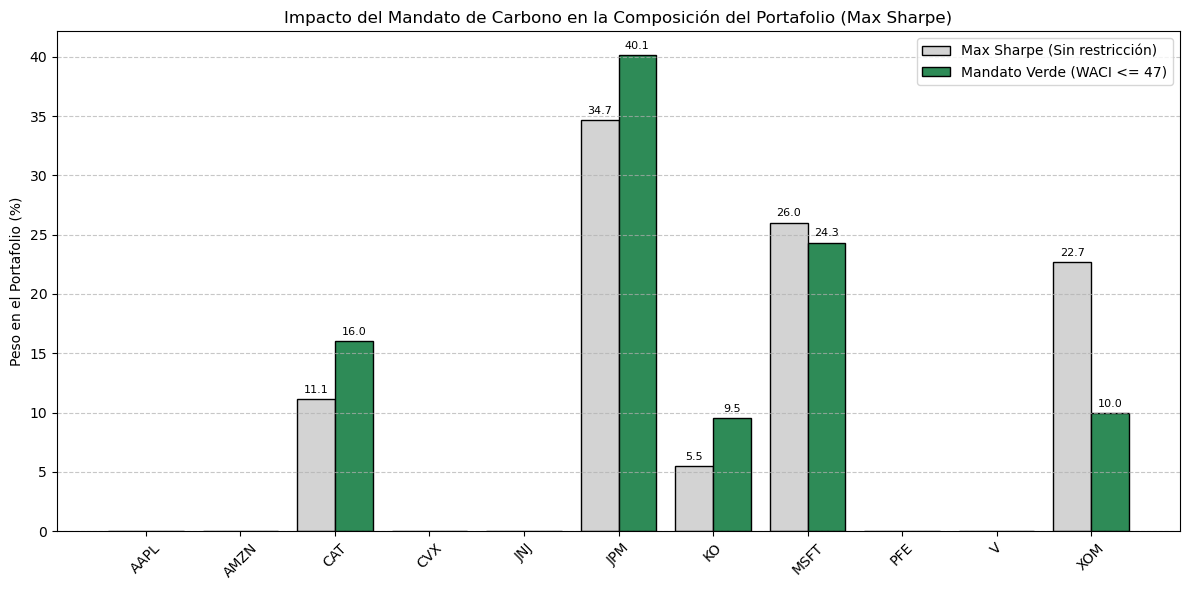

In [21]:
# Configuramos el gráfico
x = np.arange(len(empresas))  # Localización de las etiquetas
width = 0.4                   # Ancho de las barras

fig, ax = plt.subplots(figsize=(12, 6))

# Barras para el Portafolio Max Sharpe sin restricción
rects1 = ax.bar(x - width/2, w_sharpe * 100, width, 
                label='Max Sharpe (Sin restricción)', color='lightgray', edgecolor='black')

# Barras para el Portafolio con Mandato Verde
rects2 = ax.bar(x + width/2, optimal_weights * 100, width, 
                label=f'Mandato Verde (WACI <= {waci_target})', color='seagreen', edgecolor='black')

# Añadimos etiquetas y títulos
ax.set_ylabel('Peso en el Portafolio (%)')
ax.set_title('Impacto del Mandato de Carbono en la Composición del Portafolio (Max Sharpe)')
ax.set_xticks(x)
ax.set_xticklabels(empresas, rotation=45)
ax.legend()

# Añadimos una cuadrícula horizontal para facilitar la lectura
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Función para añadir el valor sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0.1: # Solo mostrar si el peso es significativo
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

## Conclusiones

La incorporación de una restricción de carbono (WACI) extiende el modelo clásico de optimización de portafolios hacia un enfoque donde el inversionista enfrenta un trade-off entre **riesgo, retorno y sostenibilidad**.

Los resultados muestran que, cuando la restricción es *binding*, el portafolio se ajusta mediante una reasignación de capital hacia activos con menor intensidad de carbono. Este proceso reduce la eficiencia financiera marginal, evidenciada en una disminución del Ratio de Sharpe.

En este ejercicio, el costo de cumplimiento es reducido (≈0.014 en el Ratio de Sharpe), lo que sugiere que la descarbonización puede lograrse con un impacto limitado sobre el desempeño financiero.

Finalmente, aunque el WACI es una métrica útil y ampliamente utilizada, presenta limitaciones, por lo que su uso debe complementarse con otros indicadores climáticos.

En conjunto, este análisis muestra que la integración de criterios climáticos en la optimización de portafolios es factible y cuantificable, permitiendo evaluar de manera explícita el costo financiero de la sostenibilidad.

## Citación

Si este trabajo resulta útil para investigación o docencia, por favor citar como:

> Ramírez-Carrillo, G. (2026). *Optimización de Portafolio Bajo un Enfoque de Mandato de Carbono*. Repositorio de GitHub. Disponible en: https://github.com/GonzaloRamirezC/green-finance-portfolio-optimization

# Bibliografía

- Markowitz, H. (1952). *Portfolio Selection*. The Journal of Finance, 7(1), 77–91.  
- Markowitz, H. (1959). *Portfolio Selection: Efficient Diversification of Investments*. John Wiley & Sons.

- MSCI (2020). *MSCI Climate Paris Aligned Indexes Methodology*. MSCI Inc.

- S&P Dow Jones Indices (2021). *S&P Paris-Aligned Climate Indices Methodology*. S&P Global.

- Task Force on Climate-related Financial Disclosures (TCFD) (2017). *Final Report: Recommendations of the TCFD*.

- Partnership for Carbon Accounting Financials (PCAF) (2022). *Global GHG Accounting and Reporting Standard for the Financial Industry*.

<p><center><font color='red' size = '4'><strong>EL PRESENTE MATERIAL HA SIDO ELABORADO CON FINES EXCLUSIVAMENTE ACADÉMICOS</strong></font></center></p>